# 1. Setup & Data Loading

In [8]:
# ============================================================
# Install dependencies & restart runtime
# Run this cell, then go to Runtime > Restart session
# ============================================================
!pip install datasets==2.14.7 huggingface_hub==0.21.4 transformers==4.40.2 -q
!pip install underthesea scikit-learn plotly kaleido pyvi -q
print("✅ Done. Now go to Runtime > Restart session, then run the next cell.")

✅ Done. Now go to Runtime > Restart session, then run the next cell.


In [1]:
# ============================================================
# Import libraries, verify GPU, and load UIT-VSFC dataset
# Pinned versions resolve HuggingFace compatibility issues
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import re
import os
from collections import Counter

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from underthesea import word_tokenize
from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU — go to Runtime > Change runtime type > T4 GPU")

print(f"datasets: {__import__('datasets').__version__}")
print(f"transformers: {__import__('transformers').__version__}")
print(f"huggingface_hub: {__import__('huggingface_hub').__version__}")

✅ GPU: Tesla T4
datasets: 2.14.7
transformers: 4.40.2
huggingface_hub: 0.21.4


In [2]:
# ============================================================
# Load UIT-VSFC — already split by authors into train/val/test
# Convert to DataFrames for convenient EDA with pandas
# ============================================================
dataset = load_dataset("uitnlp/vietnamese_students_feedback")

print("Dataset structure:")
print(dataset)
print()

train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print(f"Columns: {train_df.columns.tolist()}")
train_df.head(10)

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 3166
    })
})

Train: 11,426  |  Val: 1,583  |  Test: 3,166
Columns: ['sentence', 'sentiment', 'topic']


,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",2,0
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",1,3
7,"thời lượng học quá dài , không đảm bảo tiếp th...",0,1
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",0,1
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,0,1


In [3]:
# ============================================================
# Map numeric labels to readable names
# Verify mapping before any analysis — never assume label encoding
# ============================================================
print("Features:", dataset['train'].features)
print()

LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
LABEL_NAMES = ['Negative', 'Neutral', 'Positive']

for df in [train_df, val_df, test_df]:
    df['label_name'] = df['sentiment'].map(LABEL_MAP)

print("Label distribution in training set:")
print(train_df['label_name'].value_counts())
print()
print("Sample texts per class:")
for label in LABEL_NAMES:
    sample = train_df[train_df['label_name'] == label]['sentence'].iloc[0]
    print(f"  [{label}]: {sample[:100]}...")

Features: {'sentence': Value(dtype='string', id=None), 'sentiment': ClassLabel(names=['negative', 'neutral', 'positive'], id=None), 'topic': ClassLabel(names=['lecturer', 'training_program', 'facility', 'others'], id=None)}

Label distribution in training set:
label_name
Positive    5643
Negative    5325
Neutral      458
Name: count, dtype: int64

Sample texts per class:
  [Negative]: đi học đầy đủ full điểm chuyên cần ....
  [Neutral]: em sẽ nợ môn này , nhưng em sẽ học lại ở các học kỳ kế tiếp ....
  [Positive]: slide giáo trình đầy đủ ....


# 2. Exploratory Data Analysis

In [4]:
# ============================================================
# Class distribution across splits
# Imbalanced classes bias the model toward majority — check early
# ============================================================
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['Train', 'Validation', 'Test'],
    specs=[[{"type": "pie"}, {"type": "pie"}, {"type": "pie"}]]
)

for i, (name, df) in enumerate([('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = df['label_name'].value_counts()
    fig.add_trace(
        go.Pie(
            labels=counts.index,
            values=counts.values,
            name=name,
            marker_colors=['#EF553B', '#636EFA', '#00CC96'],
            textinfo='label+percent',
            hole=0.3
        ),
        row=1, col=i+1
    )

fig.update_layout(
    title_text="Sentiment Distribution Across Splits",
    height=400,
    showlegend=False
)
fig.show()

print("\nDetailed distribution:")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{name}:")
    total = len(df)
    for label in LABEL_NAMES:
        count = (df['label_name'] == label).sum()
        print(f"  {label}: {count:,} ({count/total*100:.1f}%)")


Detailed distribution:

Train:
  Negative: 5,325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5,643 (49.4%)

Val:
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)

Test:
  Negative: 1,409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1,590 (50.2%)


In [5]:
# ============================================================
# Text length analysis — determines PhoBERT max_length setting
# Too short = truncation loses info, too long = wasted GPU memory
# ============================================================
train_df['char_length'] = train_df['sentence'].str.len()
train_df['word_count'] = train_df['sentence'].str.split().str.len()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Character Length Distribution', 'Word Count Distribution']
)

for label in LABEL_NAMES:
    subset = train_df[train_df['label_name'] == label]
    fig.add_trace(
        go.Histogram(x=subset['char_length'], name=label, opacity=0.7, nbinsx=50),
        row=1, col=1
    )
    fig.add_trace(
        go.Histogram(x=subset['word_count'], name=label, opacity=0.7, nbinsx=50,
                      showlegend=False),
        row=1, col=2
    )

fig.update_layout(
    title_text="Text Length by Sentiment Class (Training Set)",
    barmode='overlay',
    height=450
)
fig.show()

print("Text length statistics (words):")
print(train_df.groupby('label_name')['word_count'].describe().round(1))
print()

for threshold in [64, 128, 256]:
    exceeds = (train_df['word_count'] > threshold).sum()
    pct = exceeds / len(train_df) * 100
    print(f"Texts > {threshold} words: {exceeds:,} ({pct:.1f}%)")

Text length statistics (words):
             count  mean   std  min  25%   50%   75%    max
label_name                                                 
Negative    5325.0  16.9  12.1  2.0  9.0  13.0  21.0  159.0
Neutral      458.0   9.8   8.4  2.0  5.0   7.0  12.0   79.0
Positive    5643.0  12.2   7.1  2.0  8.0  10.0  15.0   95.0

Texts > 64 words: 44 (0.4%)
Texts > 128 words: 1 (0.0%)
Texts > 256 words: 0 (0.0%)


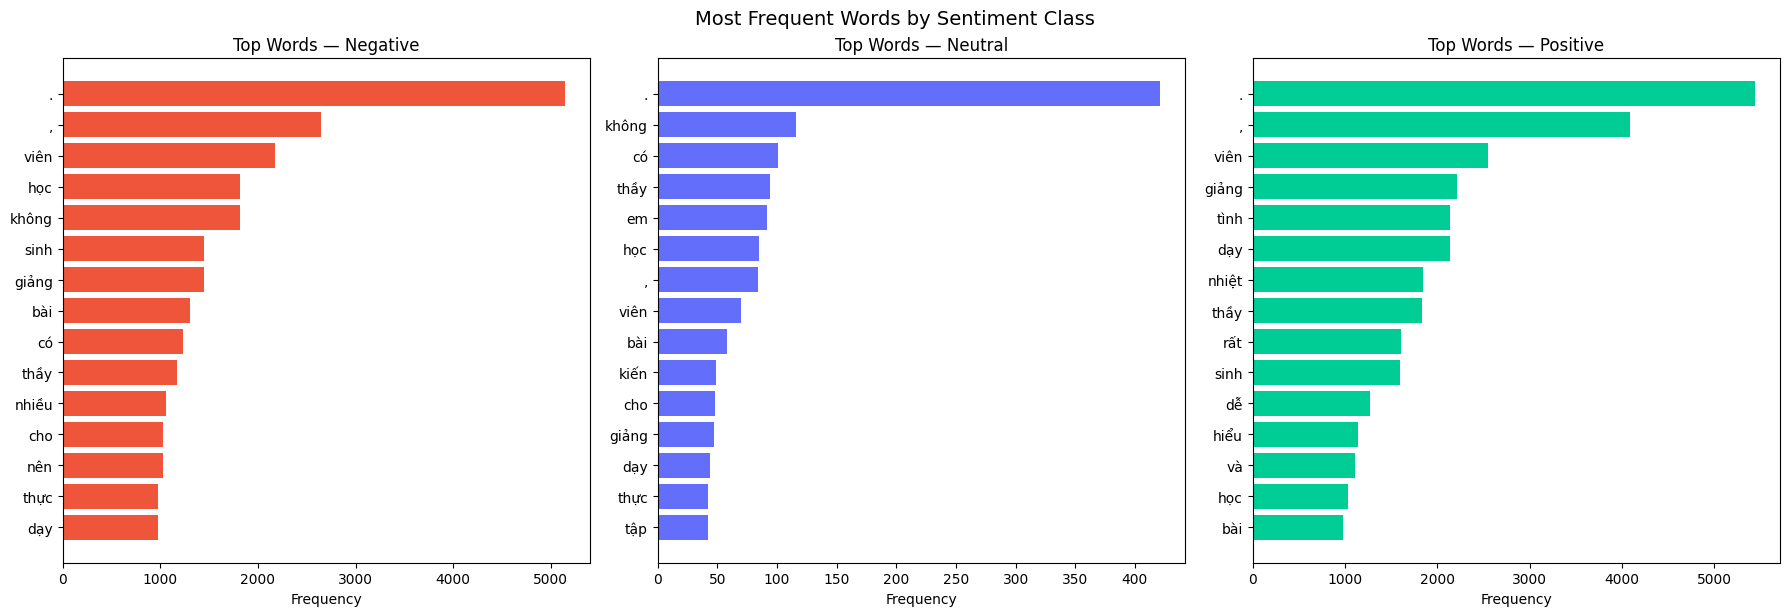

In [6]:
# ============================================================
# Most frequent words per sentiment class
# Reveals whether classes have distinctive vocabulary
# ============================================================
def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        all_words.extend(text.lower().split())
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, label in enumerate(LABEL_NAMES):
    subset = train_df[train_df['label_name'] == label]['sentence']
    top_words = get_top_words(subset, n=15)
    words, counts = zip(*top_words)

    axes[idx].barh(range(len(words)), counts, color=['#EF553B', '#636EFA', '#00CC96'][idx])
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Top Words — {label}')
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.suptitle('Most Frequent Words by Sentiment Class', y=1.02, fontsize=14)
plt.show()

In [8]:
# ============================================================
# Data quality checks — duplicates, missing values, cross-split leakage
# Catch issues now before they silently corrupt training
# ============================================================
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)

print("\n1. Missing Values:")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    nulls = df['sentence'].isnull().sum()
    empty = (df['sentence'].str.strip() == '').sum()
    print(f"  {name}: {nulls} null, {empty} empty strings")

print("\n2. Duplicates (within split):")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dupes = df['sentence'].duplicated().sum()
    print(f"  {name}: {dupes} duplicate texts ({dupes/len(df)*100:.1f}%)")

print("\n3. Cross-Split Leakage:")
train_texts = set(train_df['sentence'])
val_texts = set(val_df['sentence'])
test_texts = set(test_df['sentence'])

leak_train_val = len(train_texts & val_texts)
leak_train_test = len(train_texts & test_texts)
leak_val_test = len(val_texts & test_texts)

print(f"  Train ∩ Val: {leak_train_val} shared texts")
print(f"  Train ∩ Test: {leak_train_test} shared texts")
print(f"  Val ∩ Test: {leak_val_test} shared texts")

if leak_train_test > 0:
    print("  ⚠️ WARNING: Train-test leakage detected!")
else:
    print("  ✅ No train-test leakage.")

print("\n4. Contradictory Labels:")
duped = train_df[train_df['sentence'].duplicated(keep=False)]
if len(duped) > 0:
    contradictions = duped.groupby('sentence')['sentiment'].nunique()
    contradictory = (contradictions > 1).sum()
    print(f"  {contradictory} texts have conflicting sentiment labels")
else:
    print("  No duplicates to check")

DATA QUALITY REPORT

1. Missing Values:
  Train: 0 null, 0 empty strings
  Val: 0 null, 0 empty strings
  Test: 0 null, 0 empty strings

2. Duplicates (within split):
  Train: 1 duplicate texts (0.0%)
  Val: 0 duplicate texts (0.0%)
  Test: 0 duplicate texts (0.0%)

3. Cross-Split Leakage:
  Train ∩ Val: 0 shared texts
  Train ∩ Test: 0 shared texts
  Val ∩ Test: 0 shared texts
  ✅ No train-test leakage.

4. Contradictory Labels:
  1 texts have conflicting sentiment labels
